#Set up

In [ ]:
import os
os.getcwd()

'/content'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
data = ('/content/drive/My Drive/Colab Notebooks/SocialMediaPosts/MatchTextLength1204/01OrginalData/')
result = ('/content/drive/My Drive/Colab Notebooks/SocialMediaPosts/MatchTextLength1204/02DataForAnalysis/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import libraries
import numpy as np
import pandas as pd
import re
import string
import os
import math
import csv
import shutil, sys

import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Data Preprocessing

In [ ]:
# load the data
df = pd.read_csv(data + 'AlzheimersSocietyDementia091624.csv')
df.head()

,creation_time,id,is_branded_content,lang,link_attachment.caption,link_attachment.description,link_attachment.link,link_attachment.name,media_type,modified_time,...,statistics.sad_count,statistics.share_count,statistics.views,statistics.views_date_last_refreshed,statistics.wow_count,surface.type,surface.id,surface.name,surface.username,text
0,2024-09-16T08:00:05-07:00,1194189368473753,False,en,NaN,NaN,NaN,NaN,albums,2024-09-16T08:00:16-07:00,...,5.0,12,NaN,NaN,0.0,page,1604582253678945,Alzheimer's Society,alzheimerssocietyuk,Shocking new data has shown that people living...
1,2024-09-14T13:00:08-07:00,876509984034979,False,en,NaN,NaN,NaN,NaN,albums,2024-09-14T13:02:08-07:00,...,4.0,6,17947.0,2024-09-14,0.0,page,1604582253678945,Alzheimer's Society,alzheimerssocietyuk,‘I never imagined dementia impacting our lives...
2,2024-09-13T01:00:06-07:00,504272658995638,False,en,NaN,NaN,NaN,NaN,albums,2024-09-13T01:01:46-07:00,...,1.0,80,22868.0,2024-09-14,0.0,page,1604582253678945,Alzheimer's Society,alzheimerssocietyuk,We know there is a long way to go when it come...
3,2024-09-12T01:00:01-07:00,1286548565846038,False,en,NaN,NaN,NaN,NaN,photos,2024-09-16T06:36:48-07:00,...,5.0,15,25540.0,2024-09-14,0.0,page,1604582253678945,Alzheimer's Society,alzheimerssocietyuk,‘It felt like we had just been given a label a...
4,2024-09-11T01:00:08-07:00,1732177377594090,False,en,NaN,NaN,NaN,NaN,albums,2024-09-14T09:14:57-07:00,...,2.0,128,32993.0,2024-09-14,0.0,page,1604582253678945,Alzheimer's Society,alzheimerssocietyuk,"As part of #WorldAlzheimersMonth, we asked car..."


clean the "text": remove emoji, URLs, hashtags

In [ ]:
# Function to clean text

import re
import pandas as pd

def clean_text(text):
    # Check if the input is a string
    if isinstance(text, str):

      #Convert text to lowercase
        text = text.lower()

        # Remove new lines and extra spaces
        text = text.replace('\n', ' ').strip()

        # Remove hyperlinks (URLs)
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # Remove hashtags
        text = re.sub(r'#\w+', '', text)

        # Remove emojis (basic pattern to match most common emojis)
        emoji_pattern = re.compile("["
                                   u"\U0001F600-\U0001F64F"  # emoticons
                                   u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                                   u"\U0001F680-\U0001F6FF"  # transport & map symbols
                                   u"\U0001F700-\U0001F77F"  # alchemical symbols
                                   u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
                                   u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
                                   u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
                                   u"\U0001FA00-\U0001FA6F"  # Chess Symbols
                                   u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
                                   u"\U00002702-\U000027B0"  # Dingbats
                                   u"\U000024C2-\U0001F251"
                                   "]+", flags=re.UNICODE)
        text = emoji_pattern.sub(r'', text)

        return text
    else:
        # Handle non-string values (e.g., return empty string or original value)
        return str(text) # or return '' or return text

In [ ]:
# Apply the cleaning function to the 'text' column
df['clean_text'] = df['text'].apply(clean_text)

df[['id', 'text',"clean_text"]].head()

,id,text,clean_text
0,1194189368473753,Shocking new data has shown that people living...,shocking new data has shown that people living...
1,876509984034979,‘I never imagined dementia impacting our lives...,‘i never imagined dementia impacting our lives...
2,504272658995638,We know there is a long way to go when it come...,we know there is a long way to go when it come...
3,1286548565846038,‘It felt like we had just been given a label a...,‘it felt like we had just been given a label a...
4,1732177377594090,"As part of #WorldAlzheimersMonth, we asked car...","as part of , we asked carers ‘what’s the one t..."


In [ ]:
df.head()

,creation_time,id,is_branded_content,lang,link_attachment.caption,link_attachment.description,link_attachment.link,link_attachment.name,media_type,modified_time,...,statistics.share_count,statistics.views,statistics.views_date_last_refreshed,statistics.wow_count,surface.type,surface.id,surface.name,surface.username,text,clean_text
0,2024-09-16T08:00:05-07:00,1194189368473753,False,en,NaN,NaN,NaN,NaN,albums,2024-09-16T08:00:16-07:00,...,12,NaN,NaN,0.0,page,1604582253678945,Alzheimer's Society,alzheimerssocietyuk,Shocking new data has shown that people living...,shocking new data has shown that people living...
1,2024-09-14T13:00:08-07:00,876509984034979,False,en,NaN,NaN,NaN,NaN,albums,2024-09-14T13:02:08-07:00,...,6,17947.0,2024-09-14,0.0,page,1604582253678945,Alzheimer's Society,alzheimerssocietyuk,‘I never imagined dementia impacting our lives...,‘i never imagined dementia impacting our lives...
2,2024-09-13T01:00:06-07:00,504272658995638,False,en,NaN,NaN,NaN,NaN,albums,2024-09-13T01:01:46-07:00,...,80,22868.0,2024-09-14,0.0,page,1604582253678945,Alzheimer's Society,alzheimerssocietyuk,We know there is a long way to go when it come...,we know there is a long way to go when it come...
3,2024-09-12T01:00:01-07:00,1286548565846038,False,en,NaN,NaN,NaN,NaN,photos,2024-09-16T06:36:48-07:00,...,15,25540.0,2024-09-14,0.0,page,1604582253678945,Alzheimer's Society,alzheimerssocietyuk,‘It felt like we had just been given a label a...,‘it felt like we had just been given a label a...
4,2024-09-11T01:00:08-07:00,1732177377594090,False,en,NaN,NaN,NaN,NaN,albums,2024-09-14T09:14:57-07:00,...,128,32993.0,2024-09-14,0.0,page,1604582253678945,Alzheimer's Society,alzheimerssocietyuk,"As part of #WorldAlzheimersMonth, we asked car...","as part of , we asked carers ‘what’s the one t..."


# K-means Clustering (Unsupervised)

Clustering will allow us to group the posts into different clusters without any labels.

K-Means is an unsupervised learning algorithm that will help us group similar posts together based on the content of their cleaned_text.

After clustering, we can analyze the groups to identify which clusters contain relevant or irrelevant posts.

## Step 1: Vectorize the Text Data

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 1: Convert text to numerical features using TF-IDF
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
  # max_features=1000, It tells the vectorizer to keep only the top 500 most important words, based on their TF-IDF scores.

X_tfidf = tfidf.fit_transform(df['clean_text'])

In [ ]:
# Get the list of words (terms) from the TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()

# Convert the TF-IDF matrix to a DataFrame
tfidf_df = pd.DataFrame(X_tfidf.toarray(), columns=feature_names)

# Display the first 5 rows of the DataFrame
print(tfidf_df.head())


        000  0333   10  100   11   12   15  150   16   18  ...  worse  wouldn  \
0  0.052727   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0     0.0   
1  0.000000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0     0.0   
2  0.000000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0     0.0   
3  0.000000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0     0.0   
4  0.000000   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...    0.0     0.0   

   write  written     wrong  wrote      year     years     young  younger  
0    0.0      0.0  0.066463    0.0  0.078491  0.000000  0.000000      0.0  
1    0.0      0.0  0.000000    0.0  0.000000  0.043479  0.063221      0.0  
2    0.0      0.0  0.000000    0.0  0.000000  0.000000  0.000000      0.0  
3    0.0      0.0  0.045029    0.0  0.000000  0.026204  0.000000      0.0  
4    0.0      0.0  0.000000    0.0  0.000000  0.000000  0.000000      0.0  

[5 rows x 1000 columns]


## Step 2: find the right number of cluster

**How Can We Know How Many Clusters We Need?**

Determining the optimal number of clusters is a key challenge in clustering algorithms like K-Means. There are several methods to help identify the best number of clusters:

**1) Elbow Method**

The Elbow Method involves running K-Means for a range of cluster numbers (e.g., from 1 to 10) and plotting the within-cluster sum of squared distances (WCSS), also known as inertia.

The idea is to find the "elbow" point where adding more clusters does not significantly improve the fit.

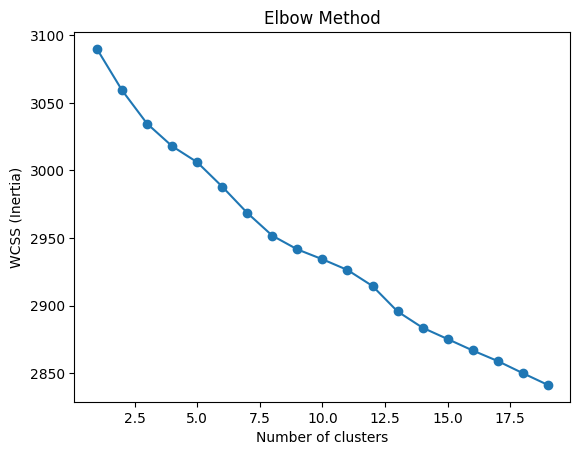

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Step 1: Calculate WCSS (inertia) for different numbers of clusters
wcss = []
for i in range(1, 20):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_tfidf)
    wcss.append(kmeans.inertia_)

# Step 2: Plot the Elbow Curve
plt.plot(range(1, 20), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Inertia)')
plt.show()


**Interpreting the Plot**: Look for an "elbow" in the plot where the WCSS (the within-cluster sum of squared distances)starts to flatten out. This indicates the point at which adding more clusters doesn't improve the model much. The number of clusters at this point is often a good choice.

**Result**: The curve doesn't have a very sharp elbow, but it seems to flatten out around 4 or 5 clusters. This suggests that choosing 4 or 5 clusters might be a reasonable choice because adding more clusters beyond that point doesn't significantly reduce the WCSS (which indicates diminishing returns in terms of improving clustering quality).

**2) Silhouette Score**

Another method is to use the Silhouette Score, which measures how similar each point is to its own cluster compared to other clusters. A higher silhouette score indicates better-defined clusters.

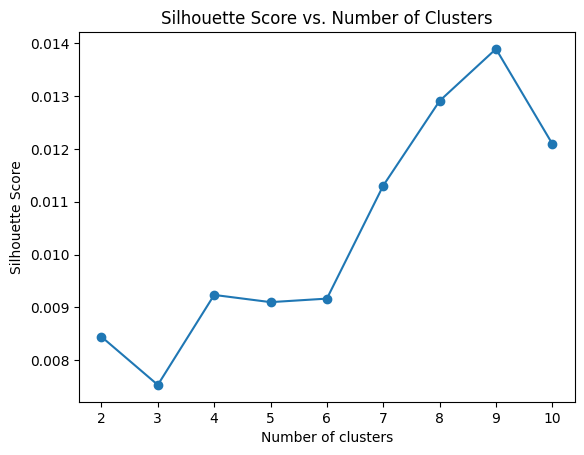

In [ ]:
from sklearn.metrics import silhouette_score

# Step 1: Compute silhouette scores for different numbers of clusters
silhouette_scores = []
for i in range(2, 11):  # Silhouette score requires at least 2 clusters
    kmeans = KMeans(n_clusters=i, random_state=42)
    cluster_labels = kmeans.fit_predict(X_tfidf)
    score = silhouette_score(X_tfidf, cluster_labels)
    silhouette_scores.append(score)

# Step 2: Plot the Silhouette Score
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()


**Interpreting the Plot**: Silhouette Score measures how similar each point is to its own cluster compared to other clusters. A higher silhouette score indicates better-defined clusters. Look for the number of clusters that gives the highest silhouette score. This suggests the optimal number of clusters.

**Result**: The Silhouette Score peaks at 9 clusters, indicating that clustering the data into 9 clusters provides the best separation and cohesiveness between clusters.


**Combined Interpretation**:
- The Elbow Method suggests that 4 or 5 clusters might be a good choice, while the Silhouette Score suggests that 9 clusters yield the best separation.

- Since the Silhouette Score is specifically designed to measure the quality of clusters, it might be preferable to go with 9 clusters based on that metric

## Step 3: Apply K-Means Clustering

We'll then apply K-Means clustering to the TF-IDF matrix to group the posts into clusters.

In [ ]:
#Apply K-Means clustering
num_clusters = 9  # You can adjust the number of clusters
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(X_tfidf)

In [ ]:
# Inspect the clusters
print(df[['clean_text', 'cluster']].head())

                                          clean_text  cluster
0  shocking new data has shown that people living...        3
1  ‘i never imagined dementia impacting our lives...        3
2  we know there is a long way to go when it come...        1
3  ‘it felt like we had just been given a label a...        3
4  as part of , we asked carers ‘what’s the one t...        4


## Step 4 visualize the clusters

- t-SNE reduces the high-dimensional TF-IDF vectors to two dimensions for visualization.
- Each point represents a post, and the color corresponds to the cluster it belongs to.
- The scatter plot will give you an idea of how the posts are grouped into clusters.

NOTE.

n_components=2: Reduces the data to 2 dimensions for easy visualization.
perplexity=30: Controls how t-SNE balances attention between local and global aspects of your data. You can experiment with this value (e.g., between 5 and 50).
n_iter=1000: The number of iterations for t-SNE. Higher values may produce a more stable embedding.

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


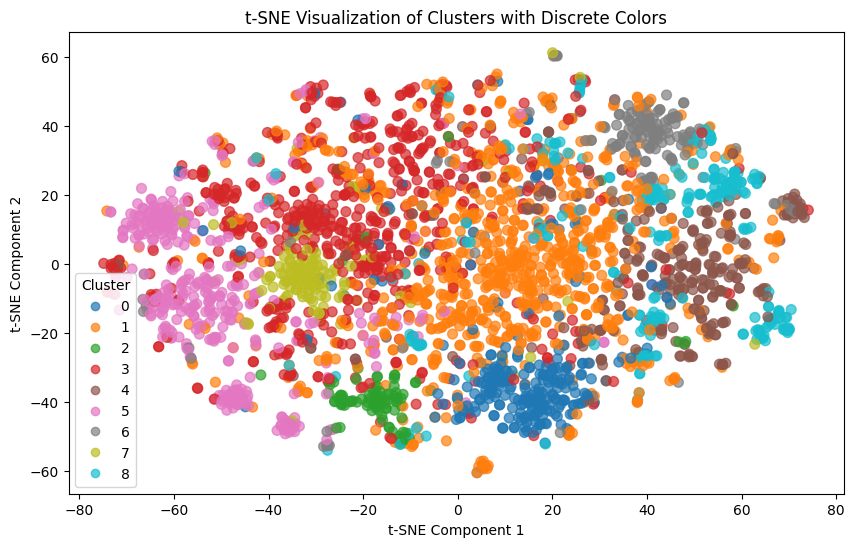

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Apply t-SNE to reduce the dimensionality to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_2d = tsne.fit_transform(X_tfidf.toarray())  # Convert sparse matrix to dense before t-SNE

# Step 2: Create a scatter plot with distinct colors for each cluster
plt.figure(figsize=(10, 6))

# Use a qualitative colormap for discrete colors (e.g., 'tab10' or 'Set1')
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df['cluster'], cmap='tab10', marker='o', s=50, alpha=0.7)

# Add titles and labels
plt.title('t-SNE Visualization of Clusters with Discrete Colors')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')

# Remove continuous color bar
plt.legend(*scatter.legend_elements(), title="Cluster")

# Show the plot
plt.show()


The visualization looks great! Now each cluster has its own distinct color, and the legend clearly shows the cluster numbers. Here's a summary of what we see:

Each point represents a post, and the points are grouped based on similarity in content.
The colors represent the 9 clusters, and each color is associated with a cluster (0 through 8), as indicated by the legend.
You can visually observe how the posts are grouped and which clusters have more density or are more spread out.

In [ ]:
# Count the number of posts in each cluster
cluster_counts = df['cluster'].value_counts()

# Display the number of posts in each cluster
print(cluster_counts)

cluster
1    883
3    675
5    410
4    336
0    270
8    260
6    168
7    158
2     99
Name: count, dtype: int64


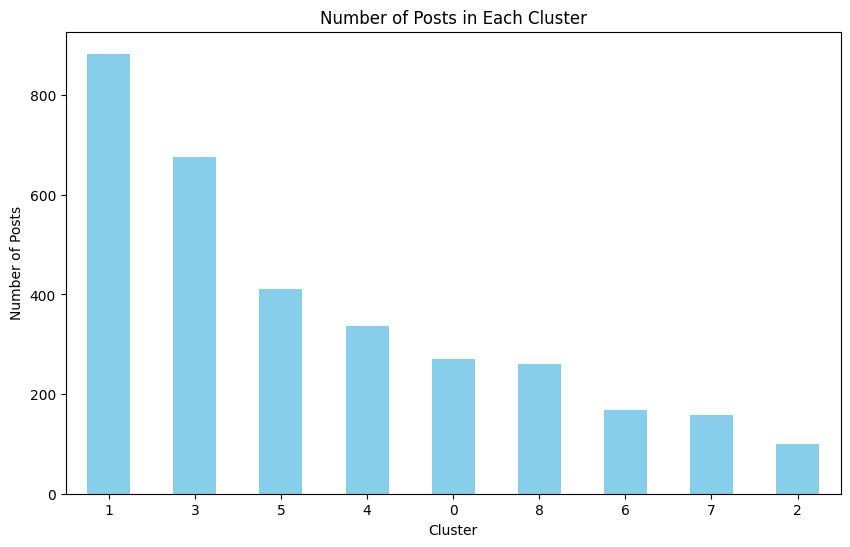

In [ ]:
# Plot the number of posts in each cluster
plt.figure(figsize=(10, 6))
cluster_counts.plot(kind='bar', color='skyblue')
plt.title('Number of Posts in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Posts')
plt.xticks(rotation=0)
plt.show()


## Step 5: Analyze the Clusters

After clustering, each post will be assigned a cluster label (stored in the cluster column). You can inspect the posts in each cluster to see which ones might correspond to irrelevant or promotional content.

Identify irrelevant or promotional content: Look for clusters that contain keywords or posts that look like advertisements or promotional content.
Group similar posts: See if clusters are grouping posts around specific topics (e.g., discussions about a particular issue).
Refine your approach: If certain clusters seem mixed (containing both relevant and irrelevant content), you might adjust the clustering or use additional filtering.

**(1) Extract Top Words for Each Cluster**

We’ll first extract top 10 words for each cluster using the TF-IDF matrix. These top words will give us a general idea of what each cluster is about.

In [ ]:
# Get the feature names (words) from the TF-IDF vectorizer
terms = tfidf.get_feature_names_out()

# Print the top 10 words for each cluster
for i in range(num_clusters):
    print(f"Cluster {i}:")
    # Get the indices of the top terms in the cluster center (centroid)
    top_terms_indices = np.argsort(kmeans.cluster_centers_[i])[-15:]  # Top 10 terms
    top_terms = [terms[ind] for ind in top_terms_indices]
    print(", ".join(top_terms))
    print("\n")

Cluster 0:
affected, help, campaign, families, support, living, residents, need, homes, government, social, people, dementia, home, care


Cluster 1:
uk, society, today, awareness, new, week, friendly, make, friends, affected, support, help, living, people, dementia


Cluster 2:
special, affected, support, make, year, tips, help, living, time, shop, festive, people, carols, dementia, christmas


Cluster 3:
know, family, diagnosis, just, like, support, time, love, life, alzheimer, diagnosed, story, years, dad, dementia


Cluster 4:
ways, difficult, important, support, caring, advice, tips, carers, look, factsheet, risk, help, people, dementia, person


Cluster 5:
challenge, help, people, fundraising, day, society, raised, alzheimer, money, sign, year, raise, dementia, memory, walk


Cluster 6:
treatments, care, disease, funding, help, new, news, uk, people, researchers, today, cure, alzheimer, dementia, research


Cluster 7:
life, day, diagnosis, diagnosed, support, just, time, alzheime

**(2) Inspect Posts in Each Cluster**

Once we’ve looked at the top words, we can further inspect the actual content of the posts in each cluster to better understand the theme of each group.






```
# Inspect a few posts from each cluster
for i in range(num_clusters):
    print(f"Cluster {i} posts:")
    sample_posts = df[df['cluster'] == i]['cleaned_text'].head(10)  # Get first 5 posts from cluster i
    for post in sample_posts:
        print(f"- {post}")
    print("\n")
```




In [ ]:
import numpy as np

# Get the feature names (words) from the TF-IDF vectorizer
terms = tfidf.get_feature_names_out()

# Inspect a few posts from each cluster along with top 10 words
for i in range(num_clusters):
    print(f"Cluster {i} posts:")

    # Get the top 10 words for this cluster
    top_terms_indices = np.argsort(kmeans.cluster_centers_[i])[-10:]  # Top 10 terms
    top_terms = [terms[ind] for ind in top_terms_indices]

    # Print the top 10 words
    print(f"Top words: {', '.join(top_terms)}")

    # Get the sample posts from the cluster
    sample_posts = df[df['cluster'] == i]['clean_text'].head(5)  # Get first 5 posts from cluster i
    for post in sample_posts:
        print(f"- {post}")

    print("\n")  # Newline for readability between clusters


Cluster 0 posts:
Top words: living, residents, need, homes, government, social, people, dementia, home, care
- ‘’it was unbearable to watch him in such constant distress, and for so many staff to continually disregard both his anguish and mine.'  last week, skills for care have published a workforce strategy for social care. they brought in experts from all over the sector, including us, to help them develop it. kerry, whose husband charles had lewy body dementia, told us a bit about their experience of care and highlights the challenges people living with dementia face when care staff haven’t been given the right training and support.  ‘after a 4-hour terrifying hallucination and with a gastrointestinal blockage, charles was taken to a&e in october 2023. following five weeks in hospital, he was discharged to a nursing home.  ‘most carers seemed not to be interested in how charles needed to be cared for, with one carer laughing at him when he became distressed whilst being washed. some

**if you want to see the posts in Cluster 0, you can do this:**

In [ ]:
# Filter posts in cluster 0
cluster_0_posts = df[df['cluster'] == 0]

cluster_0_posts[['clean_text']].head(10)

,clean_text
39,‘’it was unbearable to watch him in such const...
59,have you pledged to make dementia a priority a...
95,‘i was 46 years old when i was diagnosed. i wa...
207,"‘unless you care for someone with dementia, it..."
210,virtual wards – also known as ‘hospital at hom...
240,today's cqc report is a stark reminder of the ...
279,deciding if a person with dementia should move...
325,'it's very challenging; there's a lot of hurdl...
384,'my grandmother’s diagnosis was a life-changin...
387,"‘before you accept a place, do the questioning..."


## Step6 delete rows with specific clusters

In [ ]:
# Count the number of unique types in the 'cluster' column
num_unique_clusters = df['cluster'].nunique()
print("Number of unique clusters:", num_unique_clusters)

# Display the unique values in the 'cluster' column
unique_clusters = df['cluster'].unique()
print("Unique clusters:", unique_clusters)

Number of unique clusters: 9
Unique clusters: [3 1 4 8 5 7 0 6 2]


In [ ]:
# Drop rows where 'cluster' is in [2, 4, 6]
df.drop(df[df['cluster'].isin([2, 4, 6])].index, inplace=True)

In [ ]:
# Count the number of unique types in the 'cluster' column
num_unique_clusters = df['cluster'].nunique()
print("Number of unique clusters:", num_unique_clusters)

# Display the unique values in the 'cluster' column
unique_clusters = df['cluster'].unique()
print("Unique clusters:", unique_clusters)

Number of unique clusters: 6
Unique clusters: [3 1 8 5 7 0]


In [ ]:
# Save the rusult
df.to_csv(result + 'AD_social_clean_data_RemovedCluster246.csv')

In [ ]:
df.columns

Index(['creation_time', 'id', 'is_branded_content', 'lang',
       'link_attachment.caption', 'link_attachment.description',
       'link_attachment.link', 'link_attachment.name', 'media_type',
       'modified_time', 'multimedia', 'post_owner.type', 'post_owner.id',
       'post_owner.name', 'post_owner.username', 'shared_post_id',
       'statistics.angry_count', 'statistics.care_count',
       'statistics.comment_count', 'statistics.haha_count',
       'statistics.like_count', 'statistics.love_count',
       'statistics.reaction_count', 'statistics.sad_count',
       'statistics.share_count', 'statistics.views',
       'statistics.views_date_last_refreshed', 'statistics.wow_count',
       'surface.type', 'surface.id', 'surface.name', 'surface.username',
       'text', 'clean_text', 'cluster'],
      dtype='object')